# Relationship Between Average Iteration Time and Number of Nodes

1. The code is plotting a graph to compare the average iteration time of three different algorithms (N-Body, CG, and Jacobi) against the number of nodes. The x-axis represents the number of nodes, while the y-axis represents the average iteration time in seconds.
2. The average iteration times are calculated using the [avg_time_tests.sh](scripts/avg_time_tests.sh) script located in the [scripts](scripts) directory.


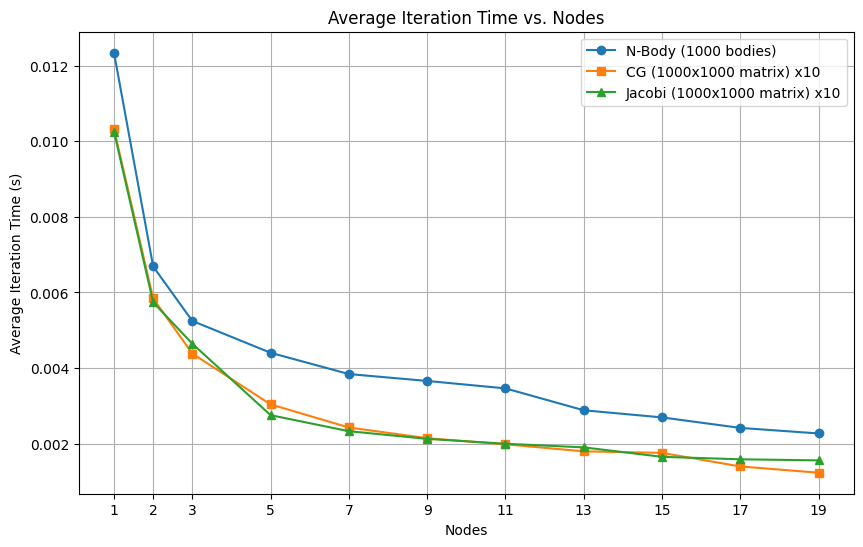

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
nodes = [1, 2, 3, 5, 7, 9, 11, 13, 15, 17, 19]

nbody_times = [0.0123434, 0.0066866, 0.0052454, 0.00440249, 0.00383915, 0.0036566, 0.00346007, 0.00288078, 0.00269195, 0.00241402, 0.00226711]
cg_times = [0.00103231, 0.000583979, 0.000438147, 0.000303633, 0.00024252, 0.000214186, 0.000198042, 0.000179386, 0.000175288, 0.000139391, 0.000122798]
jacobi_times = [0.00102571, 0.000573958, 0.000464304, 0.000275154, 0.000232704, 0.000212431, 0.000199473, 0.000189909, 0.000164903, 0.000158321, 0.000155477]

# Plot Average Iteration Time vs. Nodes
plt.figure(figsize=(10, 6))
plt.plot(nodes, nbody_times, marker='o', label='N-Body (1000 bodies)')
plt.plot(nodes, [t * 10 for t in cg_times], marker='s', label='CG (1000x1000 matrix) x10')
plt.plot(nodes, [t * 10 for t in jacobi_times], marker='^', label='Jacobi (1000x1000 matrix) x10')
plt.xlabel('Nodes')
plt.xticks(nodes)
plt.ylabel('Average Iteration Time (s)')
plt.title('Average Iteration Time vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()


# Speedup as a Function of the Number of Nodes
1. The code above calculates the speedup for the N-Body, CG, and Jacobi algorithms based on the average iteration times.
2. The average iteration times are calculated using the [avg_time_tests.sh](scripts/avg_time_tests.sh) script located in the [scripts](scripts) directory.

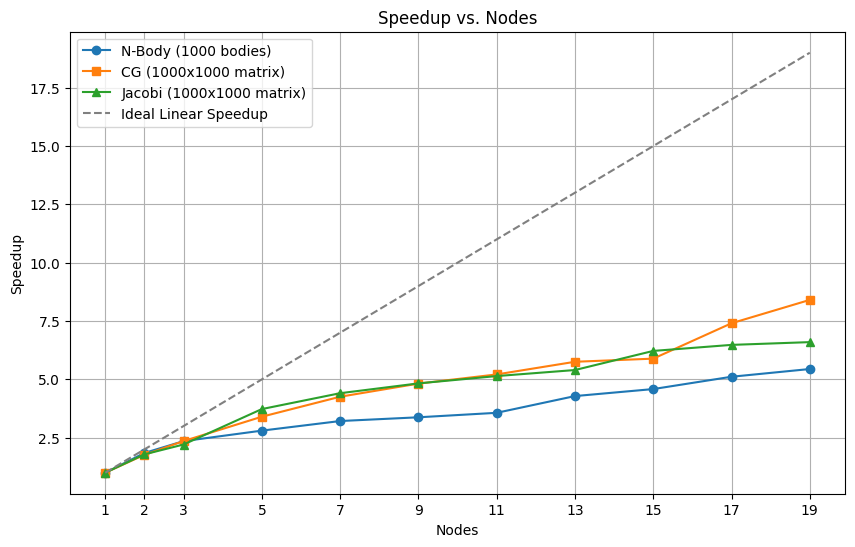

In [ ]:
nbody_speedup = [nbody_times[0] / t for t in nbody_times]
cg_speedup = [cg_times[0] / t for t in cg_times]
jacobi_speedup = [jacobi_times[0] / t for t in jacobi_times]
ideal_speedup = [node for node in nodes]

plt.figure(figsize=(10, 6))
plt.plot(nodes, nbody_speedup, marker='o', label='N-Body (1000 bodies)')
plt.plot(nodes, cg_speedup, marker='s', label='CG (1000x1000 matrix)')
plt.plot(nodes, jacobi_speedup, marker='^', label='Jacobi (1000x1000 matrix)')
plt.plot(nodes, ideal_speedup, linestyle='--', color='gray', label='Ideal Linear Speedup')
plt.xlabel('Nodes')
plt.ylabel('Speedup')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Speedup vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()



# Impact of CPU Affinity Configurations:

1. Even: Cores are assigned in even indices (0, 2, 4, ..., 38). Cores 0-18 are physical cores, while the rest are hyperthreads. Average iteration times are calculated using  [even_affinity_tests.sh](scripts/even_affinity_tests.sh)

2. Sequential (Seq): Cores are assigned sequentially from 0 to 19. All assigned cores are physical.Average iteration times are calculated using [seq_affinity_tests.sh](scripts/seq_affinity_tests.sh)

3. Even Till 18 Then Odd: Cores 0-18 are assigned in even indices (0, 2, 4, ..., 18), followed by odd indices (1, 3, 5, ...) to ensure no hyperthreads are used.Average iteration times are calculated using [even_till_18_then_odd_affinity_tests.sh](scripts/even_till_18_then_odd_affinity_tests.sh)



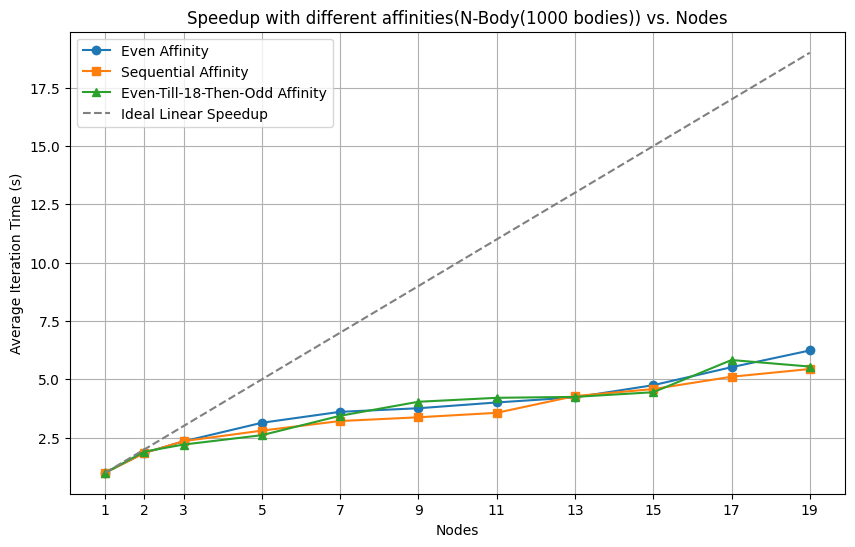

In [ ]:
# Affinity Data
nbody_even_affinity = [0.0125407, 0.00677056, 0.00534822, 0.00399388, 0.0034743, 0.00333248, 0.00312656, 0.00296433, 0.00263917, 0.00227087, 0.00200996]
nbody_seq_affinity = [0.0123434, 0.0066866, 0.0052454, 0.00440249, 0.00383915, 0.0036566, 0.00346007, 0.00288078, 0.00269195, 0.00241402, 0.00226711]
nbody_even_till_18_then_odd = [0.0133967, 0.00703467, 0.00607092, 0.0051355, 0.00389442, 0.00331529, 0.00318183, 0.00315206, 0.00301082, 0.00229799, 0.0024139]

nbody_even_speedup = [nbody_even_affinity[0] / t for t in nbody_even_affinity]
nbody_seq_speedup = [nbody_seq_affinity[0] / t for t in nbody_seq_affinity]
nbody_even_till_18_then_odd_speedup = [nbody_even_till_18_then_odd[0] / t for t in nbody_even_till_18_then_odd]

plt.figure(figsize=(10, 6))
plt.plot(nodes, nbody_even_speedup, marker='o', label='Even Affinity')
plt.plot(nodes, nbody_seq_speedup, marker='s', label='Sequential Affinity')
plt.plot(nodes, nbody_even_till_18_then_odd_speedup, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.plot(nodes, ideal_speedup, linestyle='--', color='gray', label='Ideal Linear Speedup')
plt.xlabel('Nodes')
plt.ylabel('Average Iteration Time (s)')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Speedup with different affinities(N-Body(1000 bodies)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()

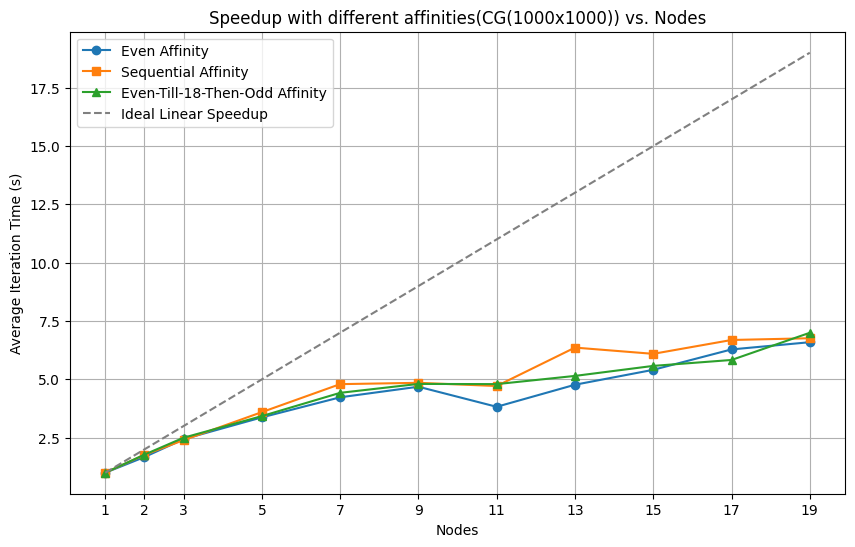

In [ ]:
cg_even_affinity = [0.00103518 ,0.00061954,0.000424665,0.000307068,0.000244601,0.000220907 ,0.00027061,0.000216984,0.000191342,0.000164729,0.000157002 ]
cg_seq_affinity = [0.00105223 ,0.00059635,0.000439177,0.000292561,0.000219385,0.000216818,0.000223132,0.000165374,0.000172638,0.000157315,0.000155576 ]
cg_even_till_18_then_odd  = [0.00105323,0.000593466,0.00042143,0.000307428,0.000238093,0.000219154 ,0.00021955,0.000204562,0.000188816,0.000180587,0.000150502]

cg_even_speedup = [cg_even_affinity[0] / t for t in cg_even_affinity]
cg_seq_speedup = [cg_seq_affinity[0] / t for t in cg_seq_affinity]
cg_even_till_18_then_odd_speedup = [cg_even_till_18_then_odd[0] / t for t in cg_even_till_18_then_odd]

plt.figure(figsize=(10, 6))
plt.plot(nodes, cg_even_speedup, marker='o', label='Even Affinity')
plt.plot(nodes, cg_seq_speedup, marker='s', label='Sequential Affinity')
plt.plot(nodes, cg_even_till_18_then_odd_speedup, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.plot(nodes, ideal_speedup, linestyle='--', color='gray', label='Ideal Linear Speedup')
plt.xlabel('Nodes')
plt.ylabel('Average Iteration Time (s)')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Speedup with different affinities(CG(1000x1000)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()


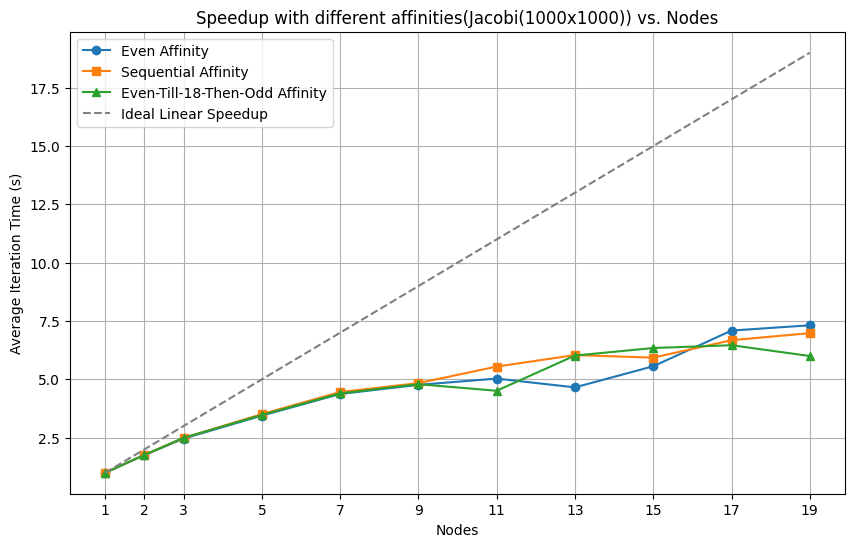

In [ ]:
jacobi_even_affinity = [ 0.00102913,0.000586082,0.000418235, 0.00029848,  0.0002352,0.000215972,0.000204425,0.000220942,0.000185003,0.000145104, 0.000140617]
jacobi_seq_affinity = [ 0.00103829,0.000589336,0.000417263,0.000295676,0.000232897,0.000214532, 0.0001871, 0.00017183,0.000175033,0.000155451,0.000148742]
jacobi_even_till_18_then_odd  = [ 0.00103979 ,0.000590383 ,0.000416632 ,0.000299273 ,0.000236353 ,0.000216906 ,0.000230419 ,0.000172678 ,0.000163893 ,0.000160842 ,0.000173262]

jacobi_even_speedup = [jacobi_even_affinity[0] / t for t in jacobi_even_affinity]
jacobi_seq_speedup = [jacobi_seq_affinity[0] / t for t in jacobi_seq_affinity]
jacobi_even_till_18_then_odd_speedup = [jacobi_even_till_18_then_odd[0] / t for t in jacobi_even_till_18_then_odd]

plt.figure(figsize=(10, 6))
plt.plot(nodes, jacobi_even_speedup, marker='o', label='Even Affinity')
plt.plot(nodes, jacobi_seq_speedup, marker='s', label='Sequential Affinity')
plt.plot(nodes, jacobi_even_till_18_then_odd_speedup, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.plot(nodes, ideal_speedup, linestyle='--', color='gray', label='Ideal Linear Speedup')
plt.xlabel('Nodes')
plt.ylabel('Average Iteration Time (s)')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Speedup with different affinities(Jacobi(1000x1000)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()


**Increased Iterations to 1M:**

To see if the trends change with increased iterations, the number of iterations has been increased from 10k to 1M. The code in the subsequent cells analyzes the impact on speedup for the Jacobi algorithm.


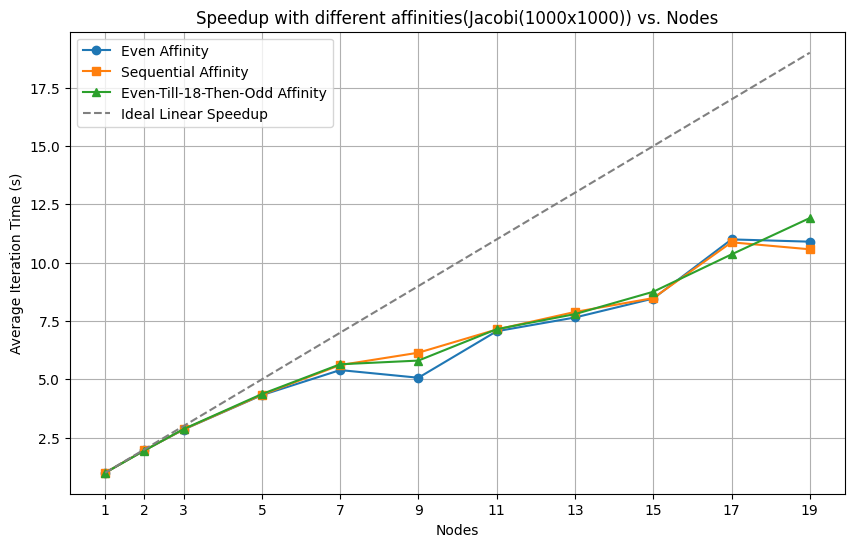

In [ ]:
# With 1M iterations
jacobi_even_affinity = [0.000933299 ,0.000476126 ,0.000327541 ,0.000215823 ,0.000172866 ,0.000184051 ,0.000132128 ,0.000121961 ,0.000110253 ,8.48476e-05 ,8.56085e-05  ]
jacobi_seq_affinity = [ 0.000932096,0.000475866,0.000326357,0.000214814,0.000166036 ,0.00015171,0.000130576,0.000118137,0.000109872,8.57118e-05,8.81412e-05 ]
jacobi_even_till_18_then_odd  = [0.000936079,0.000480135,0.000326105,0.000214176,0.000165748,0.000161226,0.000130908,0.000120048,0.000106911,9.03797e-05,7.85648e-05]

jacobi_even_speedup = [jacobi_even_affinity[0] / t for t in jacobi_even_affinity]
jacobi_seq_speedup = [jacobi_seq_affinity[0] / t for t in jacobi_seq_affinity]
jacobi_even_till_18_then_odd_speedup = [jacobi_even_till_18_then_odd[0] / t for t in jacobi_even_till_18_then_odd]

plt.figure(figsize=(10, 6))
plt.plot(nodes, jacobi_even_speedup, marker='o', label='Even Affinity')
plt.plot(nodes, jacobi_seq_speedup, marker='s', label='Sequential Affinity')
plt.plot(nodes, jacobi_even_till_18_then_odd_speedup, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.plot(nodes, ideal_speedup, linestyle='--', color='gray', label='Ideal Linear Speedup')
plt.xlabel('Nodes')
plt.ylabel('Average Iteration Time (s)')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Speedup with different affinities(Jacobi(1000x1000)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()

# Power Consumption Trends

To measure the average power consumption, we used two tools: RAPL and ePDU.

- RAPL: The  [rapl.py](scripts/rapl.py) script was used to measure the power consumption using the RAPL interface.

- ePDU: The [ePDU.py](scripts/ePDU.py) script was used to measure the power consumption using an ePDU. This script allows us to monitor the power consumption of the entire system by connecting to the ePDU and retrieving the power data.

The power consumption trends were analyzed for different CPU affinities (Even, Sequential, Even-Till-18-Then-Odd) across various nodes. The results are plotted in the graph below.


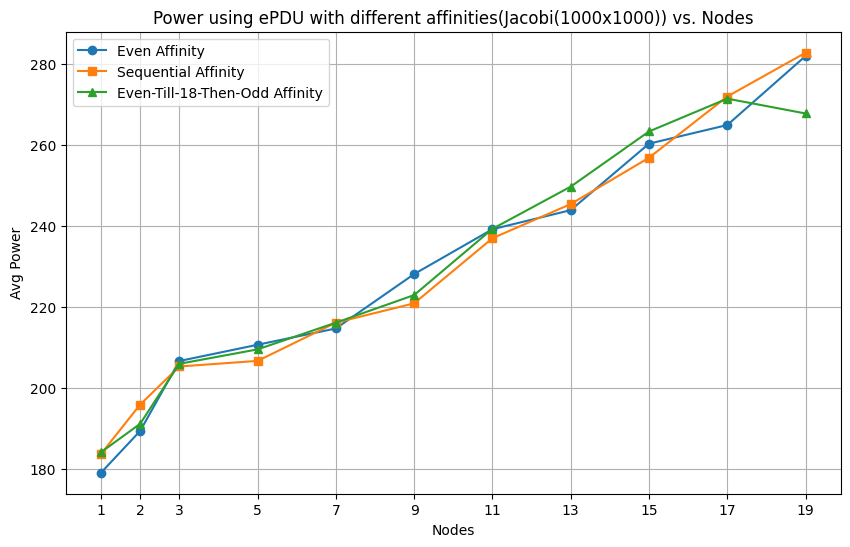

In [ ]:
jacobi_pdu_even = [179.07, 189.37, 206.63, 210.64, 214.66, 228.08, 239.14, 243.85, 260.25, 264.85, 281.87]
jacobi_pdu_seq = [183.71, 195.88, 205.28, 206.66, 216.09, 220.86, 236.92, 245.35, 256.78, 271.88, 282.69]
jacobi_pdu_even_odd = [184.13, 191.14, 205.94, 209.50, 216.09, 222.90, 239.23, 249.65, 263.26, 271.36, 267.70]


plt.figure(figsize=(10, 6))
plt.plot(nodes, jacobi_pdu_even, marker='o', label='Even Affinity')
plt.plot(nodes, jacobi_pdu_seq, marker='s', label='Sequential Affinity')
plt.plot(nodes, jacobi_pdu_even_odd, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.xlabel('Nodes')
plt.ylabel('Avg Power')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Power using ePDU with different affinities(Jacobi(1000x1000)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()


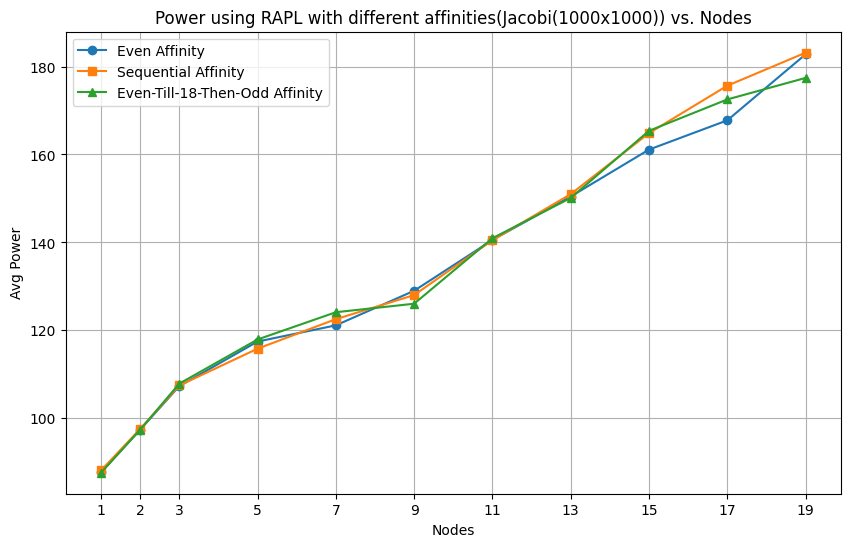

In [ ]:
jacobi_rapl_even = [87.68168852949616,97.39153247389427,107.28962642179086,117.44097498000698,121.12940545606025,128.9937782189583,140.54801658452317,150.43848255933105,161.11236171532386,167.767873119164,182.77890148565118]
jacobi_rapl_seq = [88.10409352350283,97.55548281701836,107.4447551798402,115.82068375334923,122.5348951612428,128.0128273516678,140.50008905169562,150.9857388826396,164.8593693307394,175.64881226947443,183.1552581485552]
jacobi_rapl_even_odd = [87.5975810903518,97.37588981552705,107.86477038052928,117.91415952972747,124.11277854696428,126.04789901464828,140.94300110429054,150.11514821057432,165.3882436966974,172.5249688795776,177.41995947062446]

plt.figure(figsize=(10, 6))
plt.plot(nodes, jacobi_rapl_even, marker='o', label='Even Affinity')
plt.plot(nodes, jacobi_rapl_seq, marker='s', label='Sequential Affinity')
plt.plot(nodes, jacobi_rapl_even_odd, marker='^', label='Even-Till-18-Then-Odd Affinity')
plt.xlabel('Nodes')
plt.ylabel('Avg Power')
plt.xticks(nodes)  # Show exact points on the X-axis
plt.title('Power using RAPL with different affinities(Jacobi(1000x1000)) vs. Nodes')
plt.legend()
plt.grid(True)
plt.show()